# Практическая работа № 2. Разведочный анализ данных (EDA)
**Цель:** Провести полный цикл EDA: изучить распределения, найти пропуски и выбросы, оценить корреляции.
**Данные:** Датасет выживаемости пассажиров Титаника (содержит реальные пропуски и аномалии).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Загружаем данные напрямую по ссылке, чтобы избежать проблем со скачиванием
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("ОБЩАЯ ИНФОРМАЦИЯ И ТИПЫ ДАННЫХ:")
df.info()

print("\nПРОПУСКИ В ДАННЫХ:")
print(df.isnull().sum()[df.isnull().sum() > 0])

ОБЩАЯ ИНФОРМАЦИЯ И ТИПЫ ДАННЫХ:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

ПРОПУСКИ В ДАННЫХ:
Age         177
Cabin       687
Embarked      2
dtype: int64


**Классификация признаков по типу:**
*   **Числовые непрерывные:** `Age` (возраст), `Fare` (стоимость билета).
*   **Числовые дискретные:** `SibSp` (братья/сестры на борту), `Parch` (родители/дети на борту).
*   **Категориальные номинальные:** `Sex` (пол), `Embarked` (порт посадки), `Cabin` (номер каюты).
*   **Категориальные порядковые:** `Pclass` (класс билета — 1, 2, 3).
*   **Текстовые/Уникальные:** `Name` (имя), `Ticket` (номер билета), `PassengerId`.
*   **Целевая переменная:** `Survived` (выжил/не выжил — бинарная классификация).

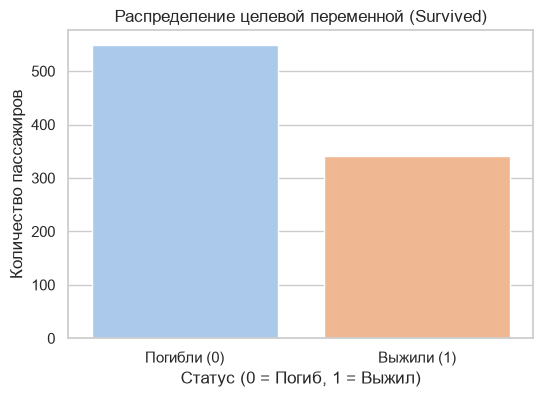

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', hue='Survived', palette='pastel', legend=False)
plt.title('Распределение целевой переменной (Survived)')
plt.xlabel('Статус (0 = Погиб, 1 = Выжил)')
plt.ylabel('Количество пассажиров')
plt.xticks([0, 1], ['Погибли (0)', 'Выжили (1)'])
plt.show()

**Вывод по целевой переменной:**
Наблюдается умеренный дисбаланс классов: погибших пассажиров (около 550) значительно больше, чем выживших (около 340). Соотношение примерно 60/40. Дисбаланс не критичный, но при обучении моделей его стоит учитывать.

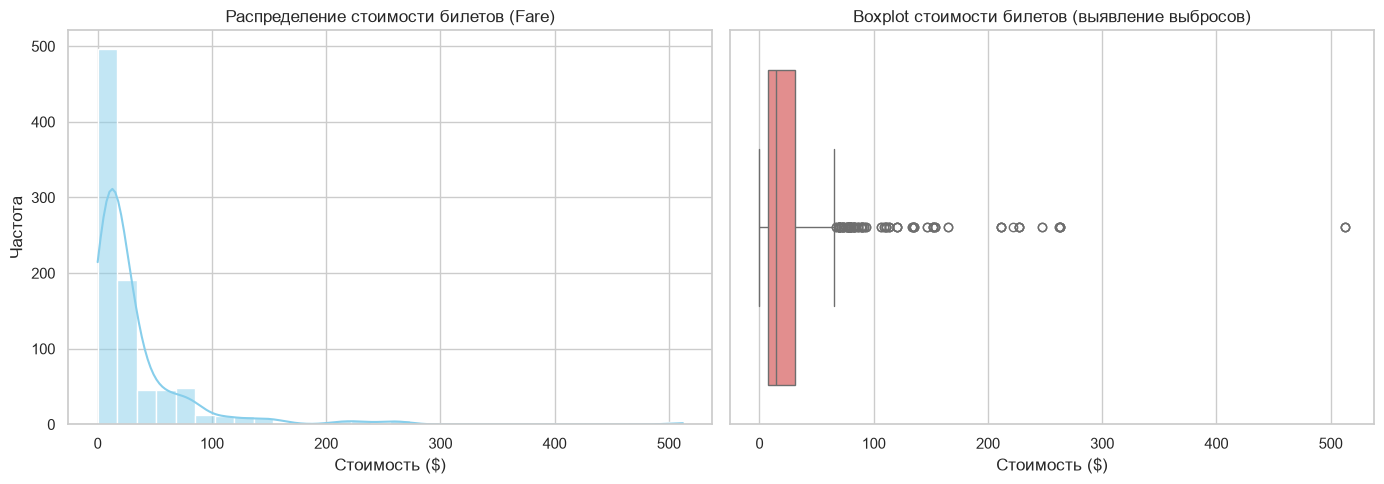

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
sns.histplot(df['Fare'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение стоимости билетов (Fare)')
axes[0].set_xlabel('Стоимость ($)')
axes[0].set_ylabel('Частота')

# Boxplot
sns.boxplot(x=df['Fare'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot стоимости билетов (выявление выбросов)')
axes[1].set_xlabel('Стоимость ($)')

plt.tight_layout()
plt.show()

**Вывод по числовым признакам (Fare):**
Гистограмма выглядит как «один столбик» с очень длинным правым хвостом. Boxplot чётко подтверждает наличие экстремальных выбросов (отдельные точки далеко за усами графика) — есть билеты стоимостью свыше 200 и даже 500 долларов, тогда как основная масса билетов стоит до 50 долларов.

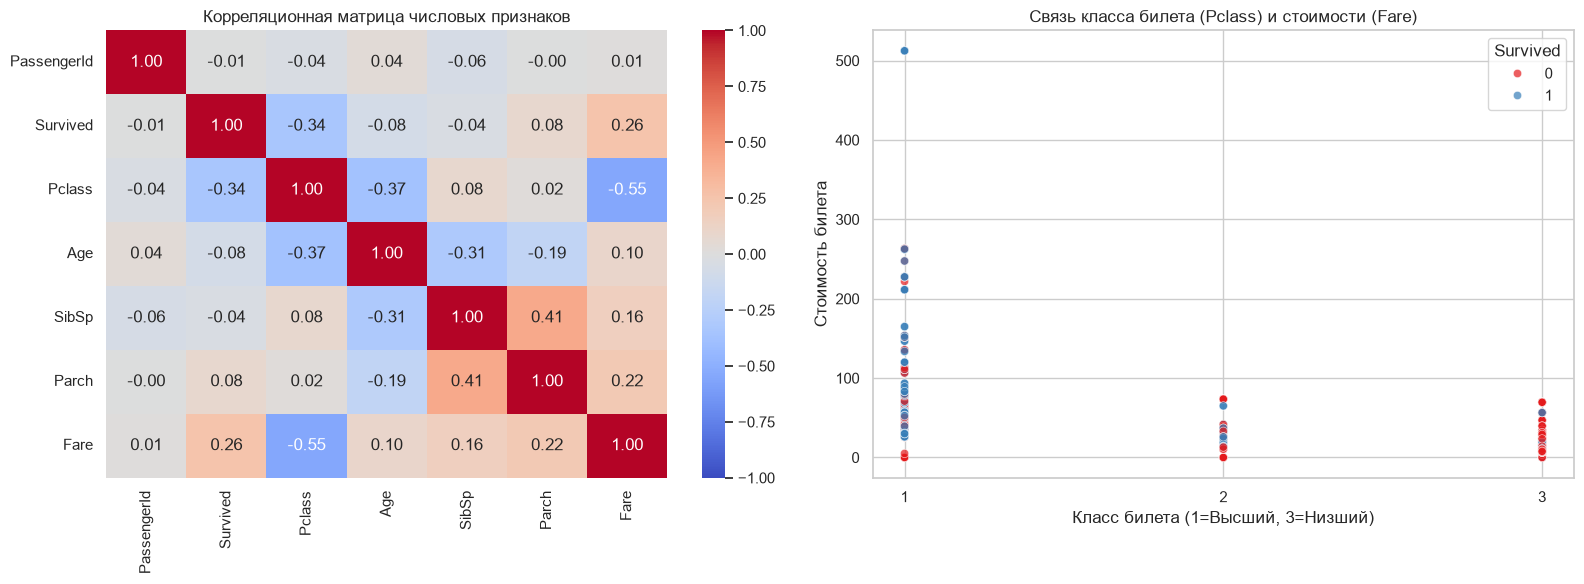

In [4]:
# Выбираем только числовые признаки для корреляции
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Тепловая карта корреляций
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Корреляционная матрица числовых признаков')

# Диаграмма рассеяния для пары с заметной связью (Pclass и Fare)
sns.scatterplot(data=df, x='Pclass', y='Fare', hue='Survived', palette='Set1', ax=axes[1], alpha=0.7)
axes[1].set_title('Связь класса билета (Pclass) и стоимости (Fare)')
axes[1].set_xlabel('Класс билета (1=Высший, 3=Низший)')
axes[1].set_ylabel('Стоимость билета')
# Настраиваем ось X, чтобы отображались только целые числа
axes[1].set_xticks([1, 2, 3]) 

plt.tight_layout()
plt.show()

**Вывод по корреляциям и связям:**
*   Наибольшая обратная корреляция (-0.55) наблюдается между `Pclass` (классом билета) и `Fare` (ценой), что логично: чем выше класс (ближе к 1), тем дороже билет.
*   На диаграмме рассеяния видно, что билеты первого класса имеют огромный разброс цен (включая все обнаруженные ранее выбросы), в то время как цены в 3 классе строго ограничены низким диапазоном. Также заметно, что среди пассажиров 1 класса плотность выживших (красные точки) визуально выше.
*   *Важно:* Корреляция не означает строгой причинно-следственной связи, но указывает на сильную линейную зависимость этих факторов.

## Отчёт: Обнаруженные проблемы данных и план их устранения

1.  **Проблема пропусков (Age):** Отсутствует 177 значений возраста. *Решение:* Заполнить медианным возрастом или использовать предиктивную импутацию (заполнение на основе других признаков, например, `Pclass` и `Sex`).
2.  **Проблема пропусков (Cabin):** Отсутствует 687 значений (более 75% данных). *Решение:* Признак слишком «дырявый», на следующем этапе его целесообразно полностью удалить из датасета.
3.  **Проблема пропусков (Embarked):** Отсутствуют 2 значения порта посадки. *Решение:* Заполнить самым частым значением (модой).
4.  **Проблема выбросов (Fare):** Наличие экстремально дорогих билетов искажает распределение. *Решение:* Применить логарифмирование признака или ограничить выбросы по 99-му перцентилю.
5.  **Неинформативные признаки:** `PassengerId`, `Name` и `Ticket` не несут математической ценности для стандартных моделей. *Решение:* Удалить эти столбцы перед подачей в алгоритм машинного обучения.
6.  **Типы данных:** Признаки `Sex` и `Embarked` представлены в виде текста. *Решение:* Применить кодирование (One-Hot Encoding или Label Encoding) для перевода их в числовой формат.